In [11]:
import pandas as pd

df = pd.read_csv(r'F:\GITHUB\Cardio-Procedures-Analysis\heart_failure_clinical_records_dataset.csv')
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


In [13]:
df.describe()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.000000,299.00000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,0.32107,130.260870,0.32107
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,0.46767,77.614208,0.46767
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,4.000000,0.00000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,73.000000,0.00000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000,0.00000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,203.000000,1.00000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000,1.00000


In [14]:
df.isnull().sum()

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64

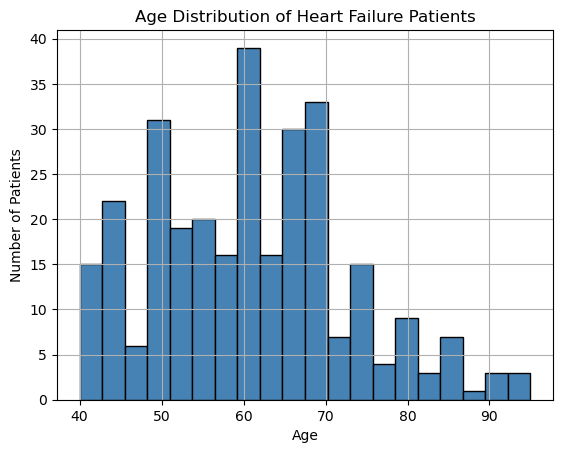

In [15]:
import matplotlib.pyplot as plt

df['age'].hist(bins=20, color='steelblue', edgecolor='black')
plt.title('Age Distribution of Heart Failure Patients')
plt.xlabel('Age')
plt.ylabel('Number of Patients')
plt.show()

In [17]:
# Age Distribution Findings:
# Patients range from 40 to ~95 years old
# Peak incidence at age 60, secondary peak at 70
# Highest risk window appears to be 50-70 years
# Lower representation of >70 may reflect prior mortality or selection bias

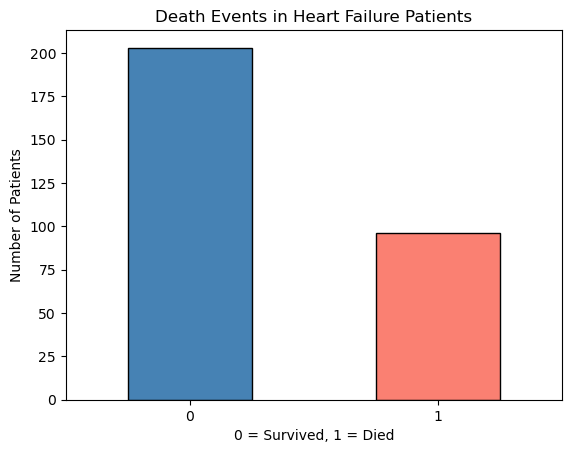

In [18]:
df['DEATH_EVENT'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'], edgecolor='black')
plt.title('Death Events in Heart Failure Patients')
plt.xlabel('0 = Survived, 1 = Died')
plt.ylabel('Number of Patients')
plt.xticks(rotation=0)
plt.show()

In [19]:
df['DEATH_EVENT'].value_counts()

DEATH_EVENT
0    203
1     96
Name: count, dtype: int64

In [24]:
# Death Event Findings:
# Total patients: 299
# Survived (0): 203 = 68%
# Died (1): 96 = 32%
# 
# 32% mortality rate reflects the severity of heart failure as a condition
# Despite relatively short follow-up period, 1 in 3 patients died
# Mortality consistent with known poor prognosis of heart failure in adults 60+

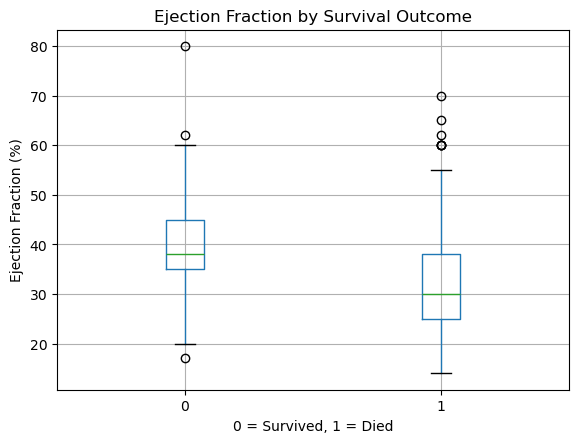

In [26]:
df.boxplot(column='ejection_fraction', by='DEATH_EVENT')
plt.title('Ejection Fraction by Survival Outcome')
plt.suptitle('')
plt.xlabel('0 = Survived, 1 = Died')
plt.ylabel('Ejection Fraction (%)')
plt.show()

In [30]:
# Ejection Fraction Findings:
# Survived (0) = EF median ~38%
# Died (1) = EF median ~30%
# Lower EF (pump) = Higher risk of death
# Lower pump output = weaker heart function = higher mortality
# Consistent with clinical definition: EF below 40% indicates heart failure

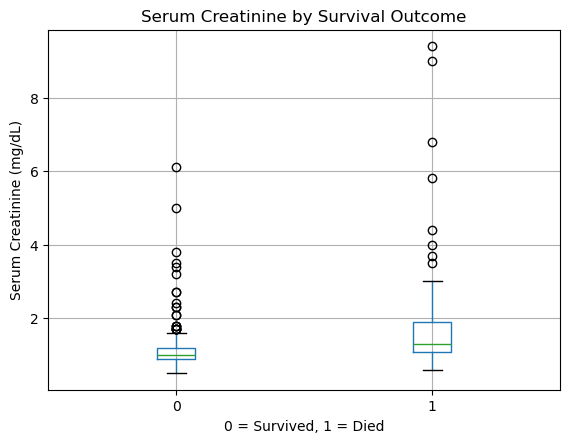

In [31]:
df.boxplot(column='serum_creatinine', by='DEATH_EVENT')
plt.title('Serum Creatinine by Survival Outcome')
plt.suptitle('')
plt.xlabel('0 = Survived, 1 = Died')
plt.ylabel('Serum Creatinine (mg/dL)')
plt.show()

In [32]:
# Serum Creatinine Findings:
# Died (1) = higher creatinine levels
# Survived (0) = lower creatinine levels
# Higher creatinine = kidneys struggling = heart failing badly
# Key predictor of mortality in heart failure patients